In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from IPython.display import display
import seaborn as sns
np.set_printoptions(precision=3, floatmode='fixed')
plt.rcParams["font.size"] = 14
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.max_columns", None)

離散分布

Text(0.5, 1.0, 'くじ引き問題の確率分布の可視化結果')

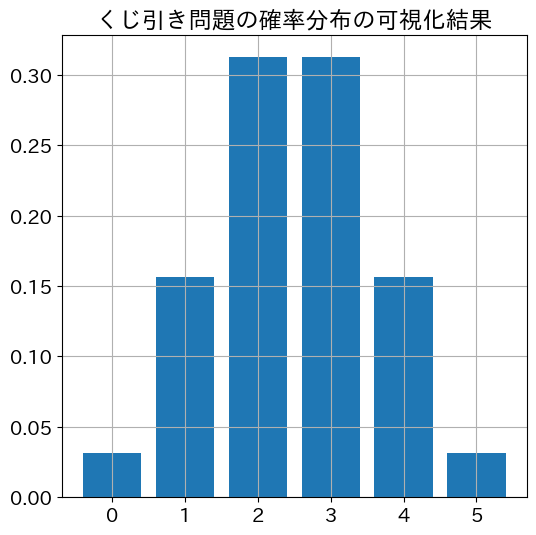

In [2]:
# くじ引き問題の確率分布の可視化
from scipy.special import comb
n = 5
x = range(n+1)
y = [comb(n,i)/2**n for i in x]
plt.bar(x,y)
plt.title("くじ引き問題の確率分布の可視化結果")

連続分布

Text(0.5, 1.0, 'くじ引き問題の確率分布の可視化結果(n=1000)')

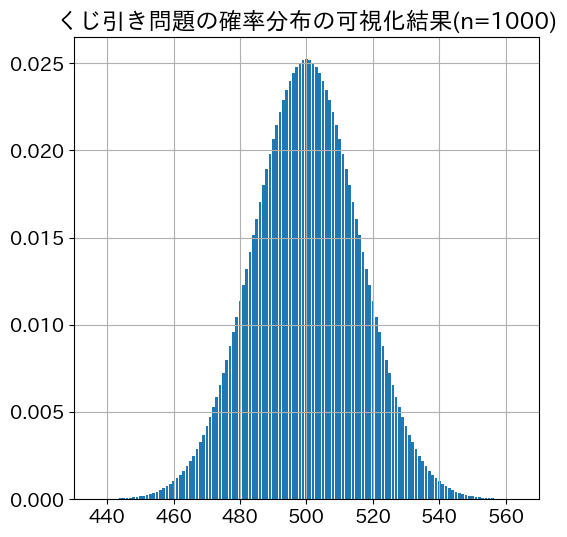

In [3]:
# n -> 1000
from scipy.special import comb
n = 1000
x = range(n+1)
y = [comb(n,i)/2**n for i in x]
plt.bar(x,y)
plt.xlim((430,570))
plt.title("くじ引き問題の確率分布の可視化結果(n=1000)")

Text(0.5, 1.0, '確率分布と正規分布関数の重ね書き')

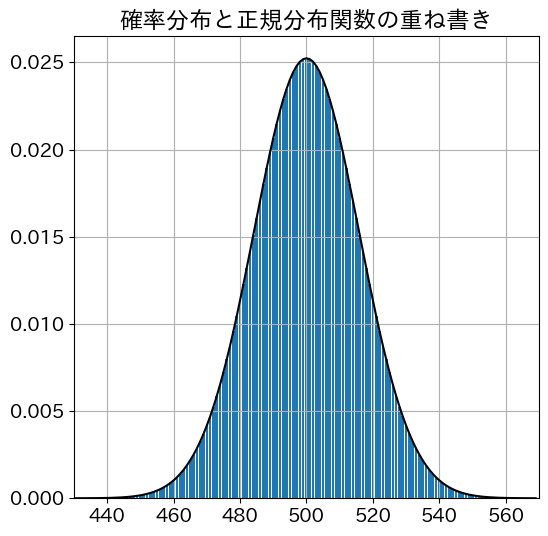

In [4]:
# 正規分布
def norm(x,mu,sigma):
    return np.exp(-((x-mu)/sigma)**2/2) / (np.sqrt(2*np.pi)*sigma)

n = 1000

plt.xlim((430,570))
x = np.arange(430,570)

y1 = [comb(n,i)/2**n for i in x]
plt.bar(x,y1)

mu = n/2
sigma = np.sqrt(mu/2)
y2 = norm(x,mu,sigma)
plt.plot(x,y2, c='k')

plt.title("確率分布と正規分布関数の重ね書き")

PyMCによる確率モデル定義とサンプリング
1. データ準備
2. 確率モデル定義
3. サンプリング
4. 結果分析

In [6]:
import pymc as pm
import arviz as az

print(f"Running on PyMC v{pm.__version__}")
print(f"Running on ArviZ v{az.__version__}")

Running on PyMC v5.27.0
Running on ArviZ v0.23.0


確率モデル定義

In [9]:
model = pm.Model()

with model:
    # Binominal
    # p
    # n
    # 'x'
    x = pm.Binomial('x', p=0.5, n=5)

サンプリング

In [17]:
# 確率モデル(事前分布)からサンプリング
# sample_prior_predictive: 事前分布の予測値取得関数
# 乱数により生成されたサンプル値がprior_samplesにセットされる

with model:
    prior_samples = pm.sample_prior_predictive(random_seed=42)

Sampling: [x]


サンプリング結果分析
1. Notebook UIを直接使用
2. Numpy形式に変換して分析
3. ArviZによる分析(ベイズ推論の結果を分析する別ライブラリ)

In [18]:
# Notebook UI
prior_samples

Inference data with groups:
	> prior

In [19]:
# Numpy形式データを抽出

x_samples = prior_samples["prior"]["x"].values
print("type: ", type(x_samples))
print("shape: ", x_samples.shape)
print("values: ", x_samples, "\n")

value_counts = pd.DataFrame(x_samples.reshape(-1)).value_counts().sort_index()
print(value_counts)


type:  <class 'numpy.ndarray'>
shape:  (1, 500)
values:  [[4 4 4 2 4 1 5 3 1 2 3 1 2 4 2 1 4 0 3 3 1 2 3 4 1 3 1 3 3 3 2 3 1 3 3 3
  0 4 3 1 2 4 3 1 3 3 2 1 1 3 3 2 2 4 4 3 4 3 4 3 5 4 3 2 3 3 3 1 1 2 1 2
  1 1 3 3 2 3 3 4 1 1 3 3 2 2 2 2 3 3 2 2 1 3 2 0 3 4 2 2 2 3 2 4 4 4 1 4
  5 3 1 4 3 3 1 3 3 2 2 3 2 3 3 4 4 1 3 3 4 3 3 4 3 5 3 3 3 2 4 3 3 2 3 3
  3 4 1 4 2 4 3 1 4 4 3 4 2 3 5 2 0 3 2 2 2 3 0 0 2 1 2 4 1 2 3 2 3 3 3 3
  2 1 3 2 2 4 2 3 3 2 2 2 1 3 1 1 3 2 3 1 3 4 3 2 2 2 2 1 2 2 2 4 4 2 2 4
  3 2 3 2 0 3 3 4 3 3 4 2 3 3 2 3 3 1 4 3 1 3 2 4 4 3 4 1 5 2 3 2 2 3 3 4
  2 1 2 4 2 2 3 1 3 3 4 2 2 4 2 2 2 4 2 1 3 2 4 2 2 3 1 2 1 2 1 4 3 5 1 3
  3 2 1 4 2 1 1 2 3 4 2 3 1 3 5 3 2 3 2 2 1 4 3 4 4 3 3 2 2 1 2 2 2 3 4 1
  3 2 3 1 4 2 1 3 3 1 2 3 2 1 1 2 1 2 2 2 2 5 2 2 1 2 4 4 3 3 1 2 5 3 3 2
  4 2 4 2 0 4 2 1 3 2 3 2 1 1 3 1 3 3 2 3 3 2 1 1 1 4 3 3 2 1 2 2 5 2 3 3
  2 1 2 4 2 4 2 2 0 3 2 2 3 1 1 4 3 3 4 4 3 4 1 5 4 3 3 5 3 4 3 3 2 2 3 2
  4 1 1 2 3 3 4 2 2 2 2 3 2 2 4 2 0 2 3 1 2 2 3 4 3 3 3

In [20]:
# ArviZによる分析

summary = az.summary(prior_samples, kind="stats")
display(summary)

,mean,sd,hdi_3%,hdi_97%
x,2.522,1.103,1.000,4.000


Text(0.5, 1.0, 'ArviZによるサンプル値の可視化結果')

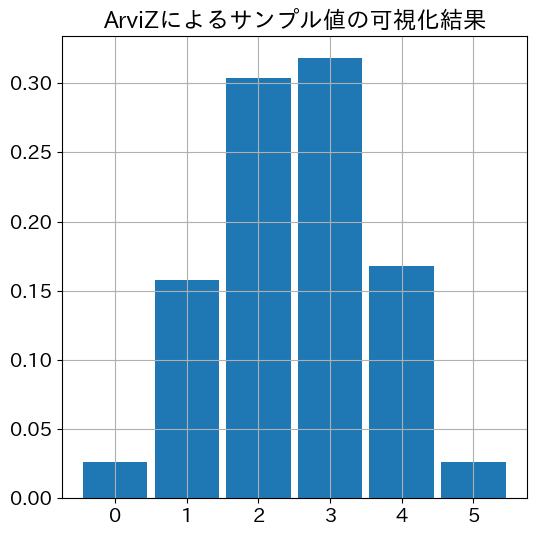

In [21]:
ax = az.plot_dist(x_samples)
ax.set_title("ArviZによるサンプル値の可視化結果")